# Part 2


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

netid = 'smaciasa'
summary = pd.read_csv(f'{netid}_project_summary.csv', sep=';')
summary['dt'] = pd.to_datetime(summary['time'], unit='s')
summary['Month'] = summary['dt'].dt.to_period('M')
projects = sorted(summary['project_wocid'].unique())
print(len(summary), 'commits in', len(projects), 'projects')

# GitHub info that was collected in part1
github = {
    'prjemian_spec2nexus':                    (3,    7,    '2026-07-20'),
    'caseywdunn_siphonophore_phylogeny_2017': (2,    1,    '2024-10-15'),
    'bc_retina':                              (14,   3,    '2025-01-20'),
    'iic-jku_ddsim':                          (162,  41,   '2026-09-28'),
    'spirit-code_spirit':                     (144,  60,   '2023-03-17'),
    'stanfordnlp_glove':                      (7230, 1545, '2025-07-27'),
    'neurodatawithoutborders_matnwb':         (62,   35,   '2026-09-27'),
    'malbecc_lio':                            (29,   18,   '2024-01-22'),
    'giaf_hpipm':                             (708,  144,  '2026-09-18'),
    'antonyuryev_elsevierapi':                ('N/A', 'N/A', 'N/A (repo deleted)'),
}

17903 commits in 10 projects


## Step 1:


In [ ]:
series = {}
for p in projects:
    counts = summary[summary['project_wocid'] == p].groupby('Month').size()
    months = pd.period_range(counts.index.min(), counts.index.max(), freq='M')
    s = counts.reindex(months, fill_value=0)
    ts = pd.DataFrame({'Month': s.index.strftime('%Y-%m'), '#Commits': s.values})
    ts.to_csv(f'{netid}_commits_timeseries_{p}.csv', sep=';', index=False)
    series[p] = ts
    print(f'{p}: {len(ts)} months, {int((ts["#Commits"] == 0).sum())} with zero commits')

series['iic-jku_ddsim'].head()

antonyuryev_elsevierapi: 58 months, 13 with zero commits
bc_retina: 127 months, 90 with zero commits
caseywdunn_siphonophore_phylogeny_2017: 93 months, 71 with zero commits
giaf_hpipm: 101 months, 20 with zero commits
iic-jku_ddsim: 71 months, 3 with zero commits
malbecc_lio: 217 months, 76 with zero commits
neurodatawithoutborders_matnwb: 99 months, 8 with zero commits
prjemian_spec2nexus: 140 months, 80 with zero commits
spirit-code_spirit: 112 months, 2 with zero commits
stanfordnlp_glove: 120 months, 76 with zero commits


,Month,#Commits
0,2020-01,6
1,2020-02,33
2,2020-03,2
3,2020-04,5
4,2020-05,0


## Step 2:

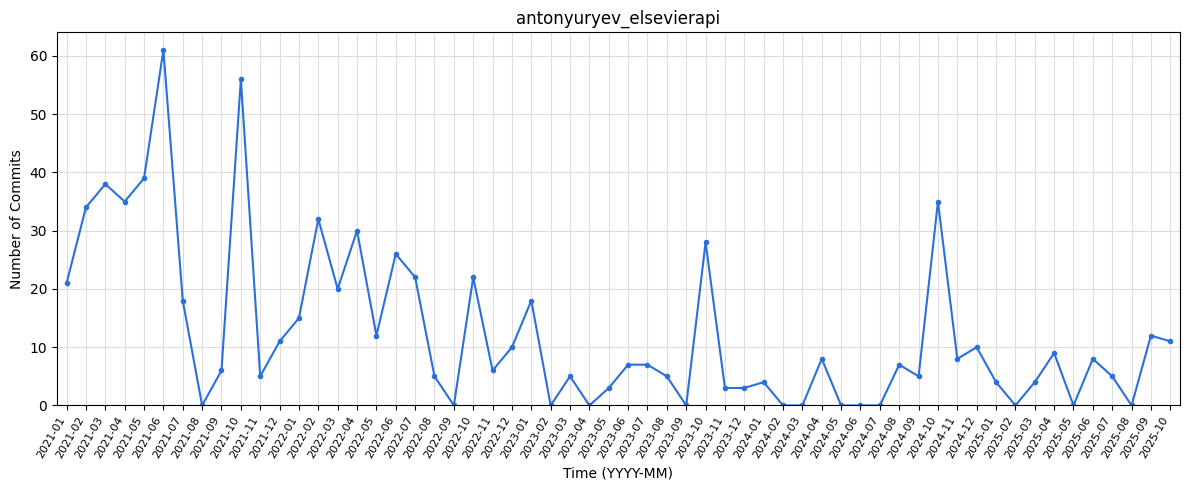

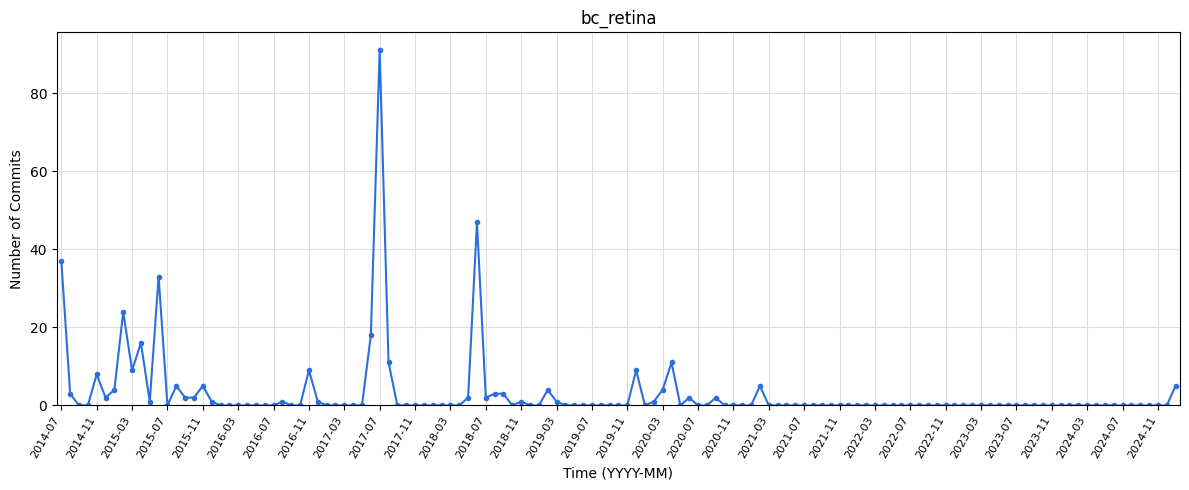

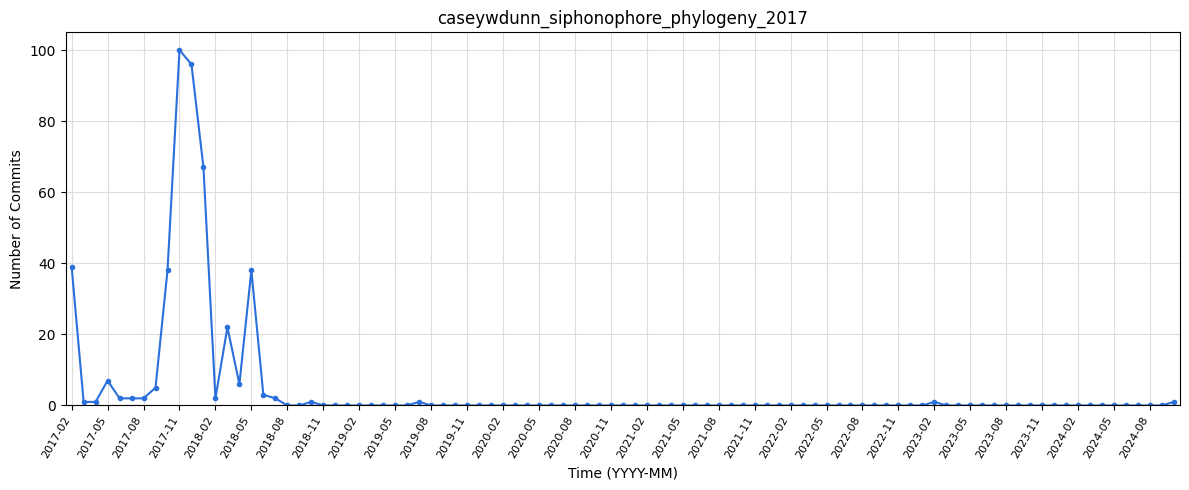

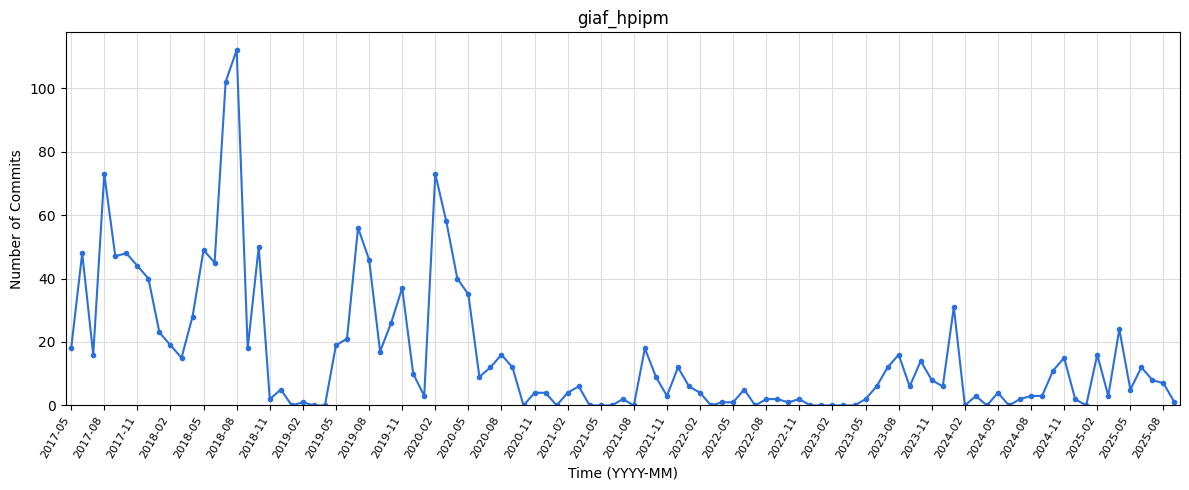

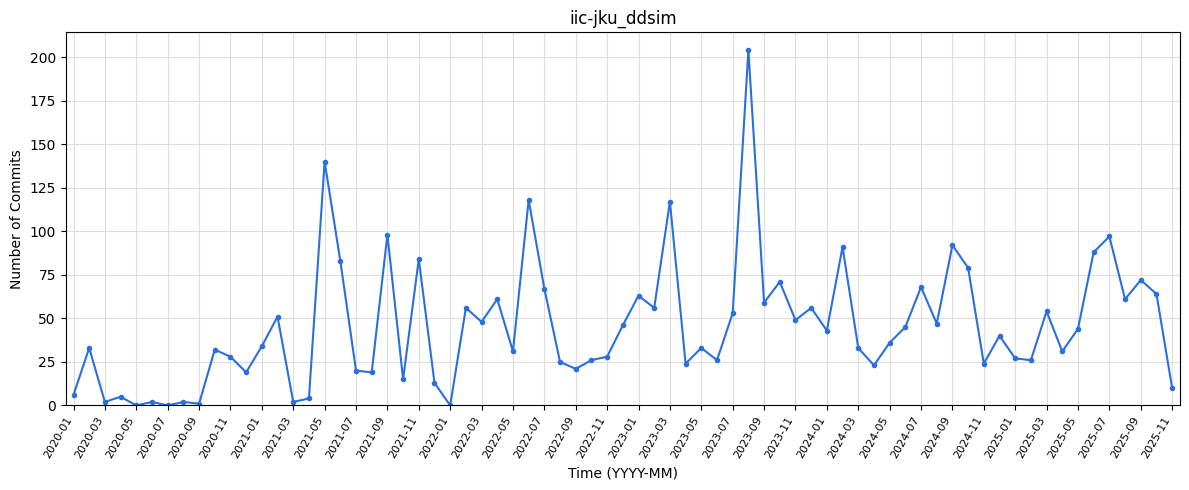

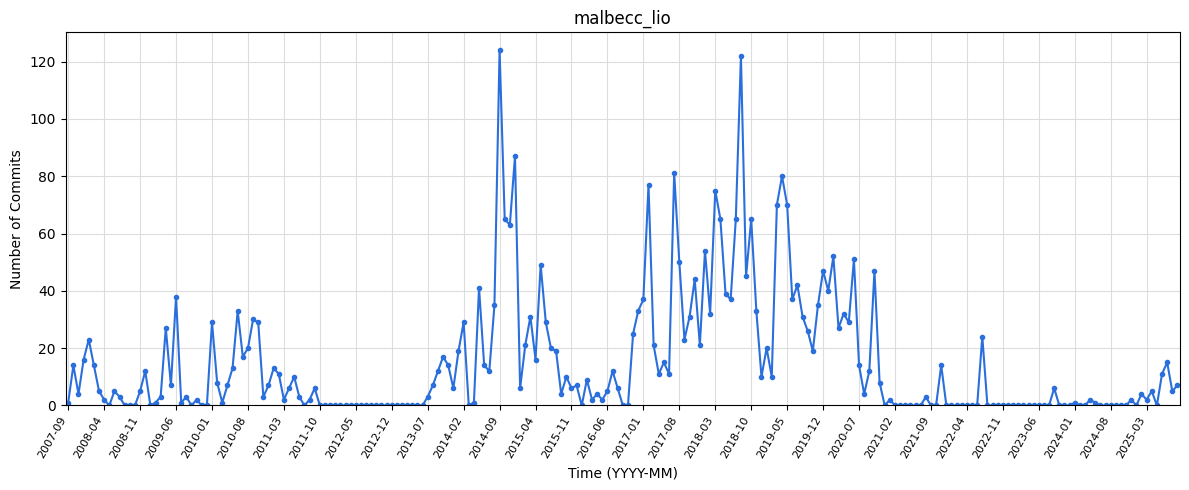

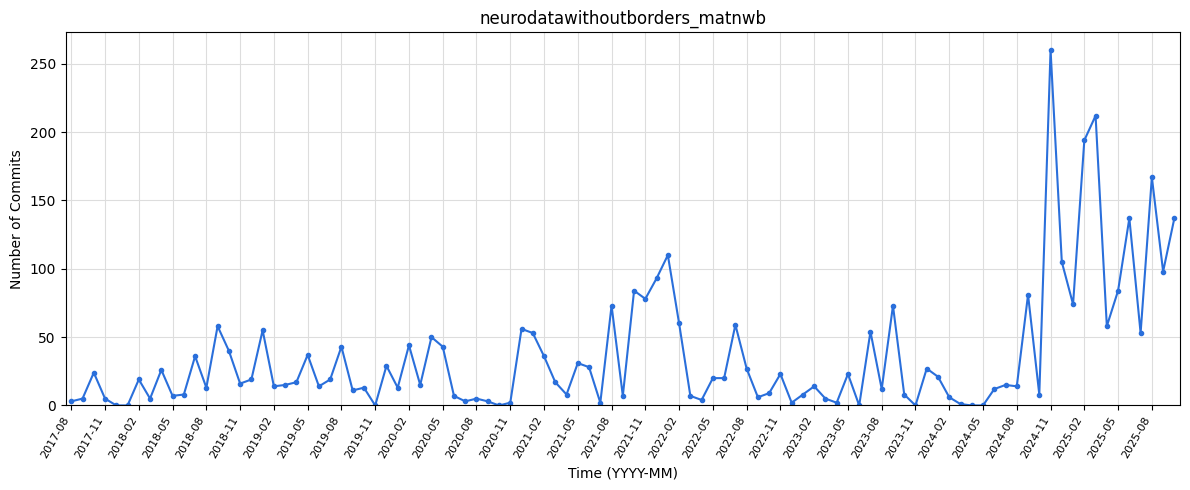

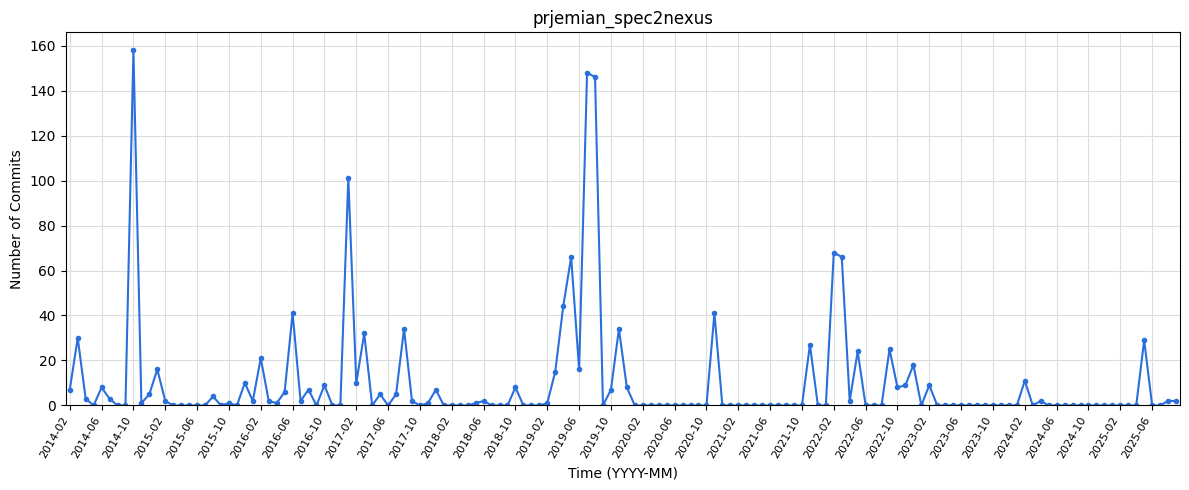

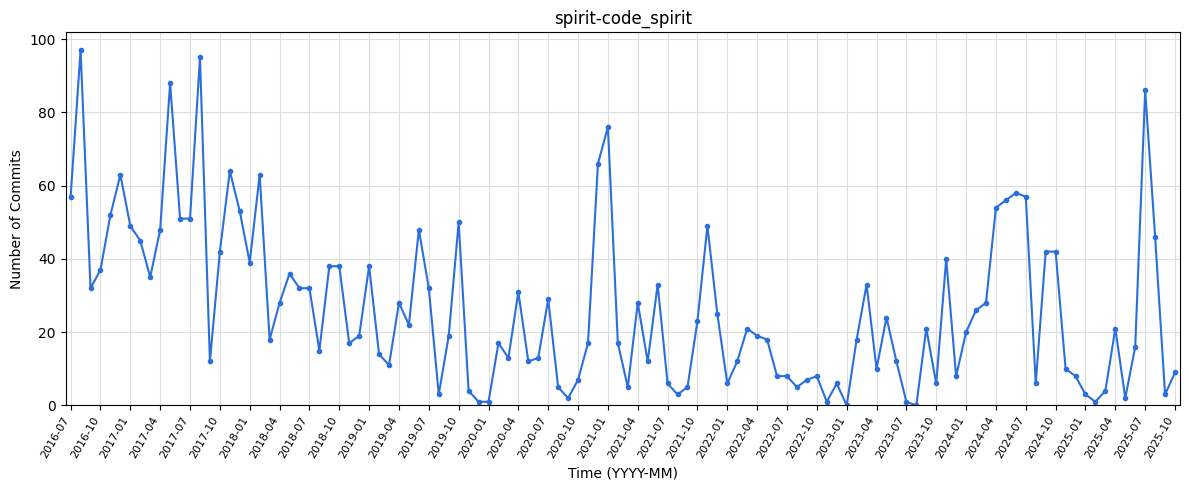

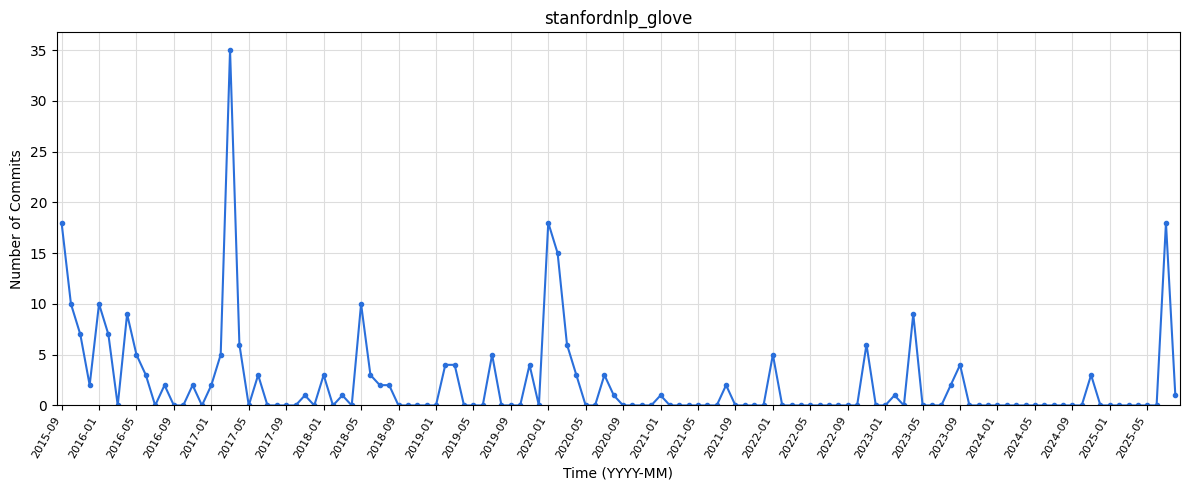

In [ ]:
for p in projects:
    ts = series[p]
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(ts['Month'], ts['#Commits'], color='#2a6fdb', linewidth=1.5, marker='o', markersize=3)
    ax.set_xlabel('Time (YYYY-MM)')
    ax.set_ylabel('Number of Commits')
    ax.set_title(p)
    ax.grid(True, color='#dddddd', linewidth=0.8)
    ax.set_axisbelow(True)
    # labels only every nth month so labels do not overlap
    step = max(1, len(ts) // 30)
    ax.set_xticks(range(0, len(ts), step))
    ax.set_xticklabels(ts['Month'][::step], rotation=60, ha='right', fontsize=8)
    ax.set_xlim(-0.5, len(ts) - 0.5)
    ax.set_ylim(bottom=0)
    fig.tight_layout()
    fig.savefig(f'{netid}_timeseries_{p}.png', dpi=300)
    plt.show()
    plt.close(fig)

## Step 3:

In [ ]:
def zero_runs(ts):
    runs, start = [], None
    for i, c in enumerate(ts['#Commits']):
        if c == 0 and start is None:
            start = i
        if c != 0 and start is not None:
            runs.append((start, i - 1)); start = None
    if start is not None:
        runs.append((start, len(ts) - 1))
    return runs

gap_rows = []
for p in projects:
    ts = series[p]
    runs = zero_runs(ts)
    if runs:
        a, b = max(runs, key=lambda r: r[1] - r[0])
        gap = dict(LongestGapStart=ts['Month'][a], LongestGapEnd=ts['Month'][b],
                   LongestGapLength=b - a + 1,
                   NumCommitsAfterLastGap=int(ts['#Commits'][b + 1:].sum()))
    else:
        gap = dict(LongestGapStart='N/A', LongestGapEnd='N/A', LongestGapLength=0,
                   NumCommitsAfterLastGap='N/A')
    gap['NumberOfGapsInTimeline'] = sum(1 for a, b in runs if b - a + 1 >= 3)
    gap['project'] = p
    gap_rows.append(gap)

gaps = pd.DataFrame(gap_rows).set_index('project')
gaps

,LongestGapStart,LongestGapEnd,LongestGapLength,NumCommitsAfterLastGap,NumberOfGapsInTimeline
project,,,,,
antonyuryev_elsevierapi,2024-05,2024-07,3,118,1
bc_retina,2021-03,2024-12,46,5,6
caseywdunn_siphonophore_phylogeny_2017,2019-08,2023-01,42,2,3
giaf_hpipm,2022-12,2023-04,5,220,2
iic-jku_ddsim,2020-05,2020-05,1,3180,0
malbecc_lio,2011-10,2013-06,21,2836,7
neurodatawithoutborders_matnwb,2017-12,2018-01,2,3575,0
prjemian_spec2nexus,2024-05,2025-04,12,33,9
spirit-code_spirit,2023-01,2023-01,1,771,0


## Step 4: Activity pattern
Picked by looking at each chart above (choices: steady, rising, declining, U-shaped, cyclical, irregular).

In [ ]:
ActivityPattern = {
    "antonyuryev_elsevierapi": "declining",
    "bc_retina": "declining",
    "caseywdunn_siphonophore_phylogeny_2017": "declining",
    "giaf_hpipm": "U-shaped",
    "iic-jku_ddsim": "steady",
    "malbecc_lio": "irregular",
    "neurodatawithoutborders_matnwb": "rising",
    "prjemian_spec2nexus": "irregular",
    "spirit-code_spirit": "U-shaped",
    "stanfordnlp_glove": "declining"
}

## Step 5:

In [ ]:
rows = []
for p in projects:
    g = summary[summary['project_wocid'] == p]
    nstars, nforks, last_gh = github[p]
    rows.append({
        'Project': p,
        'ncommits': g['commit_sha1'].nunique(),
        'nauthors': g['author'].nunique(),
        'from': int(g['time'].min()),
        'to': int(g['time'].max()),
        'nstars': nstars,
        'nforks': nforks,
        'lastGHCommitDate': last_gh,
        'LongestGapStart': gaps.loc[p, 'LongestGapStart'],
        'LongestGapEnd': gaps.loc[p, 'LongestGapEnd'],
        'LongestGapLength': gaps.loc[p, 'LongestGapLength'],
        'NumCommitsAfterLastGap': gaps.loc[p, 'NumCommitsAfterLastGap'],
        'ActivityPattern': ActivityPattern[p],
        'NumberOfGapsInTimeline': gaps.loc[p, 'NumberOfGapsInTimeline'],
    })
stats = pd.DataFrame(rows)
stats.to_csv(f'{netid}_project_stats.csv', sep=';', index=False)
print(stats.to_markdown(index=False))

| Project                                |   ncommits |   nauthors |       from |         to | nstars   | nforks   | lastGHCommitDate   | LongestGapStart   | LongestGapEnd   |   LongestGapLength |   NumCommitsAfterLastGap | ActivityPattern   |   NumberOfGapsInTimeline |
|:---------------------------------------|-----------:|-----------:|-----------:|-----------:|:---------|:---------|:-------------------|:------------------|:----------------|-------------------:|-------------------------:|:------------------|-------------------------:|
| antonyuryev_elsevierapi                |        733 |          3 | 1612075170 | 1761401938 | N/A      | N/A      | N/A (repo deleted) | 2024-05           | 2024-07         |                  3 |                      118 | declining         |                        1 |
| bc_retina                              |        385 |         15 | 1404436477 | 1737352527 | 14       | 3        | 2025-01-20         | 2021-03           | 2024-12         |            

## Interpretation

A gap here means 3 or more months in a row with zero commits.

| Project | Pattern | Gaps (3+ months) | Longest gap |
|---|---|---|---|
| antonyuryev_elsevierapi | declining | 1 | 2024-05 to 2024-07 (3 months) |
| bc_retina | declining | 6 | 2021-03 to 2024-12 (46 months) |
| caseywdunn_siphonophore_phylogeny_2017 | declining | 3 | 2019-08 to 2023-01 (42 months) |
| giaf_hpipm | U-shaped | 2 | 2022-12 to 2023-04 (5 months) |
| iic-jku_ddsim | steady | 0 | 2020-05 (1 month) |
| malbecc_lio | irregular | 7 | 2011-10 to 2013-06 (21 months) |
| neurodatawithoutborders_matnwb | rising | 0 | 2017-12 to 2018-01 (2 months) |
| prjemian_spec2nexus | irregular | 9 | 2024-05 to 2025-04 (12 months) |
| spirit-code_spirit | U-shaped | 0 | 2023-01 (1 month) |
| stanfordnlp_glove | declining | 11 | 2023-10 to 2024-10 (13 months) |

**antonyuryev_elsevierapi (declining).** This one started out really busy in 2021 with 324 commits. After that it slowed down every year. It had 200 in 2022 and then only around 50 to 80 a year. People still work on it here and there but way less than at the start. It has 1 gap.

**bc_retina (declining).** Most of the work was done between 2014 and 2018. There were two big jumps in 2017 and 2018. After 2019 things slowed way down. Then nobody touched it for almost 4 years. It only got 5 new commits in January 2025. It has 6 gaps.

**caseywdunn_siphonophore_phylogeny_2017 (declining).** Pretty much all the work happened in 2017 and 2018. The name has 2017 in it so I think it was made for one research paper. After 2018 it pretty much stopped. Only 3 more commits showed up after that. It has 3 gaps.

**giaf_hpipm (U-shaped).** This one was really busy from 2017 to 2020 with 200 to 470 commits a year. Then in 2021 and 2022 it dropped to only 25 to 55 a year. After that it got going again from 2023 to 2025 with about 70 to 75 a year. It has 2 gaps.

**iic-jku_ddsim (steady).** It was slow for the first few months in 2020. After that it kept going at 500 to 800 commits a year and never really took a break. The longest stop was only 1 month. It has 0 gaps.

**malbecc_lio (irregular).** This one goes up and down a lot and there is no real pattern. It was small from 2007 to 2011. Then it stopped for 21 months. From 2014 to 2020 it got really busy. After 2021 it got super quiet with only a few commits a year. In 2025 it started to pick up a little. It has 7 gaps.

**neurodatawithoutborders_matnwb (rising).** This one has been active the whole time and keeps getting bigger. It had around 250 commits a year at the start. It got to 523 in 2024 and then 1214 in 2025. The longest stop was only 2 months. It has 0 gaps.

**prjemian_spec2nexus (irregular).** This one works in bursts. It gets a lot of commits all at once and then goes quiet for a while. The big bursts were in 2014 and 2017 and 2019 and 2022. They do not happen on a schedule so I would not call it cyclical. The longest stop was 12 months from 2024 to 2025. It has 9 gaps.

**spirit-code_spirit (U-shaped).** It was the busiest in 2016 and 2017. Then it slowly went down and hit its lowest in 2022 and 2023 with about 120 to 170 commits a year. In 2024 it went back up to 407. It never fully stopped. The longest stop was 1 month. It has 0 gaps.

**stanfordnlp_glove (declining).** This one never had many commits even though it has the most stars by far. From 2015 to 2020 it got a small amount of work pretty regularly. After 2020 it only gets a few commits a year with long breaks in between. It has 11 gaps which is more than any other project.